In [1]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import scipy
import pickle
import os
path = os.getcwd()

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:,i_time] = maxI_
    return control_

def set_init(init_v_):
    init_vars = aln.init_vars
    for i in range(len(init_vars)):
        if aln.params[init_vars[i]].size == 1:
            aln.params[init_vars[i]][0] = init_v_[i]
        else:
            aln.params[init_vars[i]][0,-1] = init_v_[i]

In [3]:
aln = ALNModel()
aln.params['duration'] = 0.4

control0 = aln.getZeroControl()

aln.params.ext_exc_current = 1.0
aln.params.ext_inh_current = 1.0

#aln.params.signalV = 0.
#aln.params.de = 0.0
#aln.params.di = 0.0

aln.params.cee = 0.
aln.params.cei = 0.
aln.params.cie = 0.
aln.params.cii = 0.
aln.params.Ke = 0.
aln.params.Ki = 0.
aln.params.Jee_max = 1e-30
aln.params.Jei_max = 1e-30
aln.params.Jie_max = 1e-30
aln.params.Jii_max = 1e-30

#aln.params.cee = 0.1
#aln.params.cei = 0.1
#aln.params.Ke = 1000.
#aln.params.Ki = 1000.
#aln.params.Jee_max = 1.
#aln.params.Jei_max = 1.

# NO ADAPTATION
aln.params.IA_init = np.array([0.])
#aln.params.seev_init = np.array([0.001])

aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

state = aln.getZeroState()
fullState = aln.getZeroFullState()
aln.run(control = control0)

#plt.plot(aln.t, aln.rates_exc[0,:])
#plt.plot(aln.t, aln.rates_inh[0,:])

output = aln.output_vars

for i in range(len(output)):
    state[:,i,:] = aln[output[i]][:,:]

state_vars = aln.state_vars
init_vars = aln.init_vars

vars_init = np.zeros(( len(state_vars) ))
vars_init[0] = np.array( [[0.]])
vars_init[1] = np.array( [[0.]])
vars_init[2] = np.array( [2.])
vars_init[3] = np.array( [2.])
#vars_init[9] = np.array( [0.001])

In [7]:
dur = 0.4
dur_pre = 0.4
dur_post = 0
aln.params.duration = dur

control0 = aln.getZeroControl()
target = aln.getZeroTarget()

aln.run(control=control0)
print(aln.rates_exc.shape)

c_scheme = np.zeros((len(aln.output_vars), len(aln.output_vars) ))
c_scheme[0,0] = 1.
u_mat = np.identity(aln.params['N'])
u_scheme = np.array([[1, 0], [0, 0]])

max_it = 100
tol = 1e-16
incl_step = int(1. + aln.params.duration/aln.params.dt)
start_step = 1000.
test_step = 1e-12

41
(1, 45)
(1, 5)


sigma e =  1.5
seev =  0.0
r, rho = 0.0 0.0 0.0
sigma e =  1.5
seev =  0.0
r, rho = 0.059222876425586046 0.0 0.0
sigma e =  1.5
seev =  0.0
r, rho = 0.059222876425586046 0.0 0.0
sigma e =  1.5
seev =  0.0
r, rho = 0.059222876425586046 0.0 0.0
...............
exc rates =  [ 0.     59.2229 59.2229 59.2229 59.2229]
inh rates =  [ 0.     59.2229 55.366  52.2206 49.5749]
mufe =  [[2. 2. 2. 2. 2.]]
mufi =  [[2.     1.88   1.7838 1.704  1.6371]]
tau exc =  [[0.8335 0.8335 0.8335 0.8335 0.8335]]
tau inh =  [[0.8335 0.8335 0.9146 0.9821 1.0518]]
sigma =  [[1.5 1.5 1.5 1.5 1.5]]
sigma =  [[1.5 1.5 1.5 1.5 1.5]]


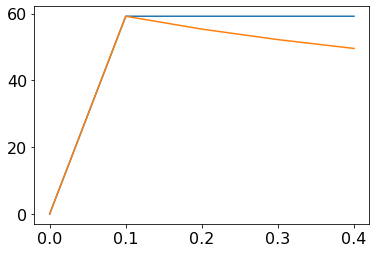

In [262]:
set_init(vars_init)
                
aln.params.duration = dur + dur_pre
cntrl_zeros_pre = int(dur_pre / aln.params.dt)
        
control1 = aln.getZeroControl()
control1[:,0,:] += 1.

aln.run(control=control1)
target[:,0,:] = aln.rates_exc[:,cntrl_zeros_pre:]
target[:,1,:] = aln.rates_inh[:,cntrl_zeros_pre:]


print("...............")
print("exc rates = ", aln.rates_exc[0,:])
print("inh rates = ", aln.rates_inh[0,:])

print("mufe = ", aln.state["mufe"])
print("mufi = ", aln.state["mufi"])

print("tau exc = ", aln.state["tau_exc"])
print("tau inh = ", aln.state["tau_inh"])

print("sigma = ", aln.state["sigmae_f"])
print("sigma = ", aln.state["sigmai_f"])

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

In [267]:
cost.setParams(1.0, 0.0, 0.)

max_it = 1
start_step = 1000.

set_init(vars_init)
control2 = aln.getZeroControl()

A1_bestControlA, A1_bestStateA, A1_costA, A1_runtimeA = aln.A1(control2, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = None)

set cost params
RUN  0 , total integrated cost =  7.8495043842385055
g_min =  [[[-0.0628 -0.0713 -0.0574 -0.0331  0.    ]
  [ 0.      0.      0.      0.      0.    ]]]
RUN  1 , total integrated cost =  0.18311552758386235
Improved over  1  iterations by  98  percent.


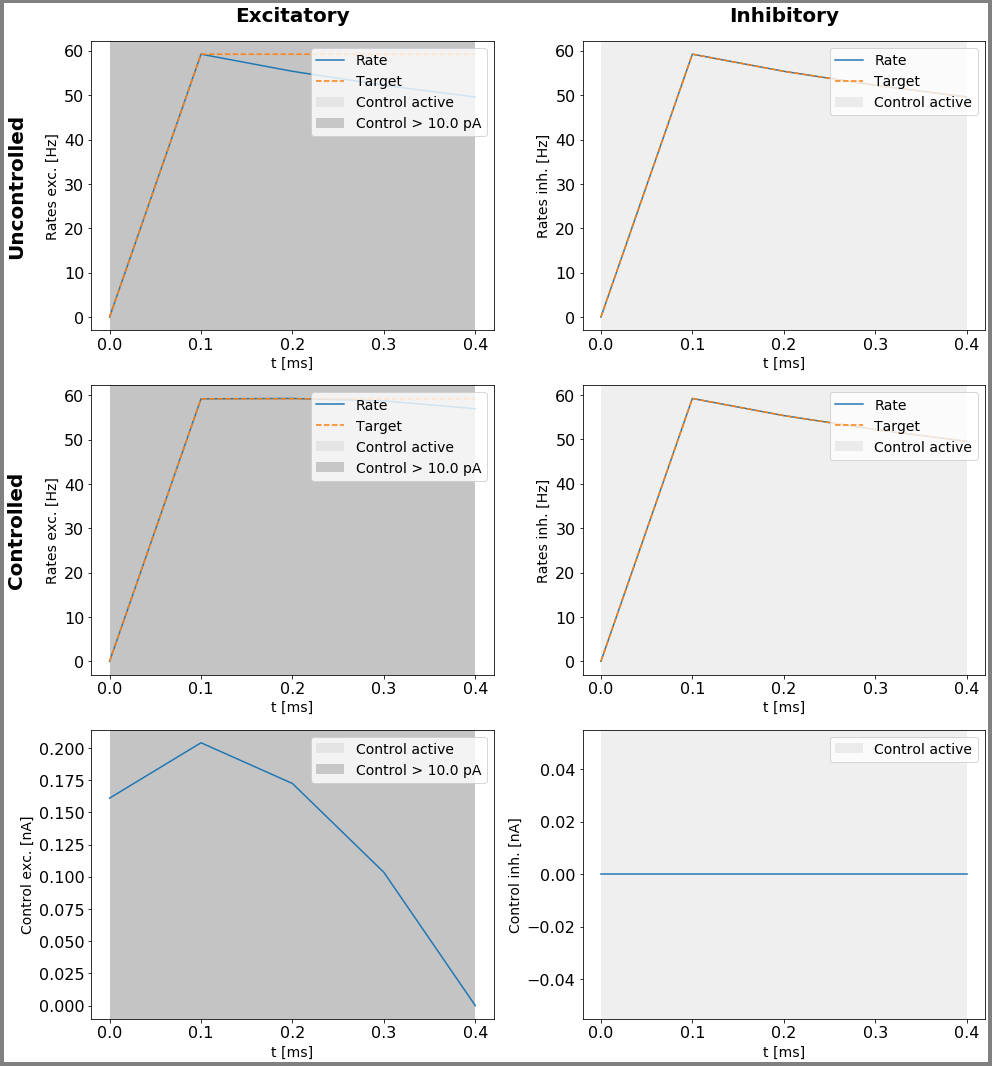

In [242]:
plotFunc.plot_control(aln, A1_bestControlA, dur, dur_pre, dur_post, vars_init, target,
                      path, filename_ = 'a1')

In [146]:
############# A2
cost.setParams(1.0, 0.0, 0.)
max_cntrl = 1000. * 5.

aln.params.duration = dur
set_init(vars_init)
control2 = aln.getZeroControl()
#control2[:,0,1] += 1.

max_it = 1
    
A2_bestControlA, A2_bestStateA, A2_costA, A2_runtimeA = aln.A2(control2, target, max_iteration_ = max_it,
        tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

set cost params
start ind =  1
RUN  0 , total integrated cost:  10648.512091895791
3  cost =  [  0.       0.     234.9719 228.5918 115.4708 161.6944 207.7986  85.9493
 140.2468 182.8187  73.8348 127.7818 173.1297 204.9096 227.2807  87.5096
 140.3729 182.033  211.4282  81.0928 134.9563 178.0107 208.6182  79.937
 133.9662 177.2619 208.0877 228.673   87.3558 140.0563 181.6272 210.9999
  80.8742 134.7289 177.8025 208.4406  79.8546 133.8867 177.1936 208.0326
 228.6305  87.3313 140.0345 181.6098 210.9866  80.8685 134.7236 177.7982
 208.4373  79.8533 133.8853 177.1926 208.0318 228.6299  87.3311 140.0343
 181.6096 210.9865  80.8684 134.7236 177.7982 208.4373  79.8532 133.8854
 177.1926 208.0318 228.6299  87.3311 140.0343 181.6096 210.9865  80.8684
 134.7236 177.7982 208.4373  79.8532 133.8853 177.1926 208.0318 228.6299
  87.3311 140.0343 181.6096 210.9865  80.8684 134.7236 177.7982 208.4373
  79.8532 133.8854 177.1926 208.0318 228.6299  87.3311 140.0343 181.6096
 210.9865  80.8684 134.7236 177

[[[0.0000e+00 2.5000e+00 2.5000e+00 ... 6.2500e-01 6.2500e-01 0.0000e+00]
  [0.0000e+00 6.2500e-01 6.2500e-01 ... 4.8828e-03 1.2207e-03 0.0000e+00]]]


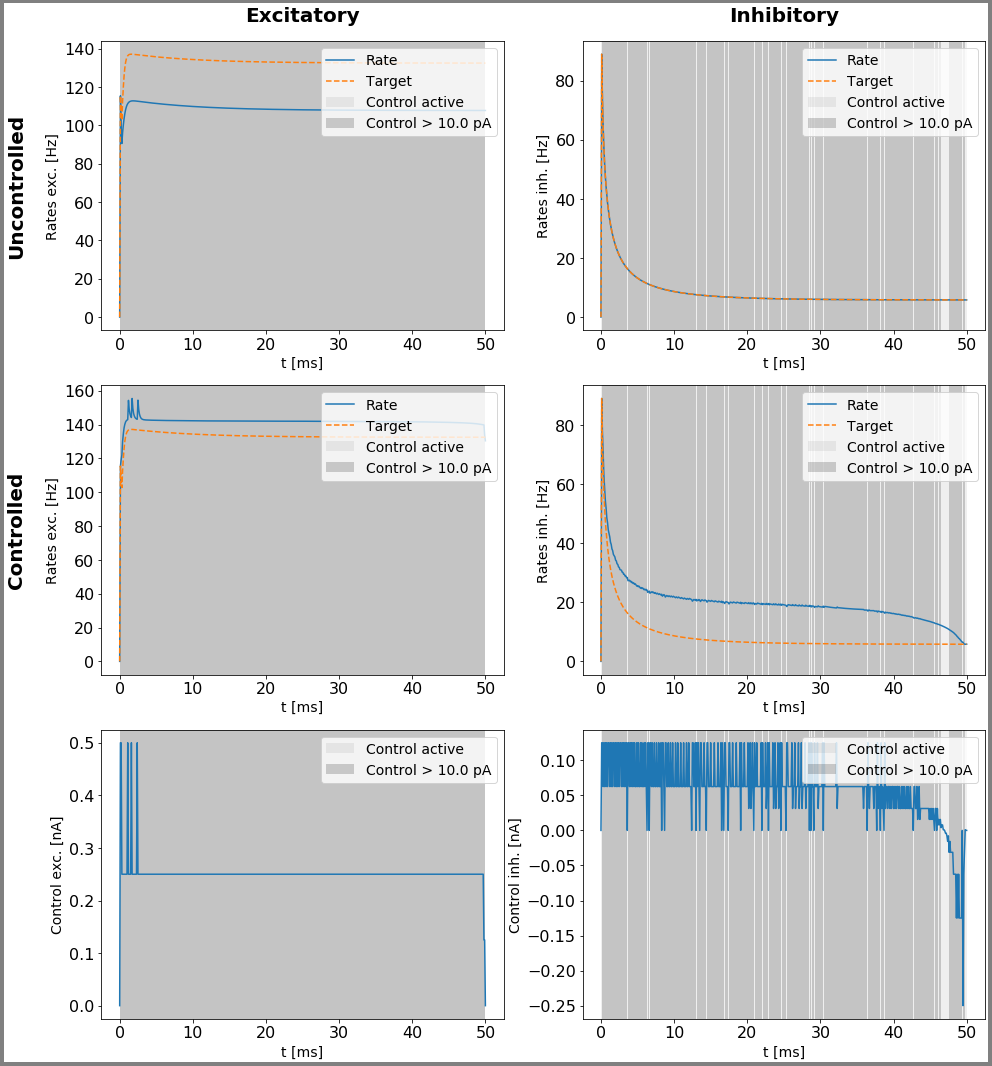

In [136]:
print(A2_bestControlA)
plotFunc.plot_control(aln, A2_bestControlA, dur, dur_pre, dur_post, vars_init, target,
                      path, filename_ = 'a2')